# Quickstart: from high-frequency data to block fluxes

Surface renewal (SR) estimates the sensible heat flux $H$ from nothing more
than a fast (10–20 Hz) air-temperature record: during daytime heating, air in
contact with the surface warms gradually and is then abruptly replaced —
"renewed" — producing characteristic asymmetric **ramps** in the temperature
trace. The amplitude and duration of those ramps carry the flux.

This tutorial walks the shortest path through the package:

1. generate a synthetic high-frequency record (swap in your own file to reuse the code),
2. look at the ramp structure the methods exploit,
3. run the full pipeline with `run_surface_renewal`, and
4. interpret the block-level output, including a peek at the third-order
   structure function that drives the ramp recovery.

The [method comparison](02_method_comparison.ipynb) and
[calibration](03_calibration.ipynb) tutorials build on the same synthetic
record.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

from surface_renewal import run_surface_renewal, PipelineConfig

# A light, recessive plot style: hairline grid behind the data, no chart junk.
plt.rcParams.update({
    "figure.figsize": (9.0, 3.6),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.color": "#e1e0d9",
    "grid.linewidth": 0.8,
    "axes.axisbelow": True,
    "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelcolor": "#52514e",
    "xtick.color": "#898781",
    "ytick.color": "#898781",
    "lines.linewidth": 1.8,
    "legend.frameon": False,
})

# Fixed series colors; each quantity keeps its color across all figures.
C_BLUE, C_AQUA, C_YELLOW, C_GREEN, C_VIOLET, C_INK = (
    "#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#52514e",
)

## Synthetic input data

The tutorials are self-contained: instead of shipping a large raw data file,
each one generates a 4-hour, 10 Hz record with the structure the SR methods
look for — gradual warming **ramps** that end in a sharp temperature drop as
the heated air parcel is swept away and renewed. With your own data you would
skip this cell and pass a `DataFrame` (or a CSV/Parquet path) with columns
`T`, `u`, `v`, `w` and, optionally, `Rn` and `G` — see the
[quick start](../quickstart.md) for the input conventions. A stand-alone copy
of a similar generator ships with the repository as `scripts/make_synthetic.py`.

In [2]:
def make_synthetic(fs=10.0, hours=4.0, seed=42, wind=1.0):
    """Synthetic high-frequency record with surface-renewal ramp structure.

    Temperature follows the classic SR ramp — a slow rise ended by a sharp
    drop (60 s period) — whose amplitude grows toward "midday" and fades
    again (the ``env`` envelope). The wind components share part of the ramp
    signal so the record carries a realistic w'T' covariance and a well-posed
    friction velocity. ``wind`` scales all wind components (1.0 = breezy,
    small values = near-calm convective conditions).
    """
    rng = np.random.default_rng(seed)
    n = int(fs * 3600 * hours)
    t = np.arange(n) / fs

    # Convective "activity" envelope: ramps grow toward midday, then fade.
    env = 0.3 + 0.7 * np.sin(np.pi * t / t[-1])
    # Classic SR ramp: slow rise, sharp drop, 60 s period.
    ramp = 2.0 * ((t % 60.0) / 60.0) - 1.0

    T = 298.15 + 0.4 * env * ramp + 0.05 * rng.standard_normal(n)
    du = 0.5 * env * ramp + 0.5 * rng.standard_normal(n)  # streamwise gusts
    u = wind * (2.5 + du)
    v = wind * (0.1 + 0.5 * du + 0.3 * rng.standard_normal(n))
    w = wind * (0.2 * du + 0.15 * rng.standard_normal(n))

    idx = pd.Timestamp("2023-06-01 08:00") + pd.to_timedelta(t, unit="s")
    df = pd.DataFrame({"T": T, "u": u, "v": v, "w": w}, index=idx)

    # Radiation terms (W m^-2) so the latent-heat residual is exercised.
    solar = 400.0 + 200.0 * np.sin(np.pi * t / t[-1])
    df["Rn"] = solar + 20.0 * rng.standard_normal(n)
    df["G"] = 0.1 * solar + 5.0 * rng.standard_normal(n)
    return df

In [3]:
df = make_synthetic()
df.head()

,T,u,v,w,Rn,G
2023-06-01 08:00:00.000,298.045236,1.902522,0.504615,-0.299596,430.892278,27.739060
2023-06-01 08:00:00.100,297.978395,2.596731,-0.040193,0.256395,396.189976,40.896986
2023-06-01 08:00:00.200,298.068310,1.610933,-0.654463,-0.276613,390.391940,38.932968
2023-06-01 08:00:00.300,298.078210,1.926922,-0.321492,-0.151564,390.324125,40.126495
2023-06-01 08:00:00.400,297.934024,2.391935,0.231685,-0.051785,413.702602,42.376470


## The ramp signature

Three minutes of the temperature trace make the surface-renewal signature
obvious: a slow, minute-scale rise ended by a sharp drop, repeating as parcels
are renewed. Everything the SR methods compute — structure functions, wavelet
scales, ramp amplitude $a$ and period $\tau$ — is a way of measuring these
ramps objectively.

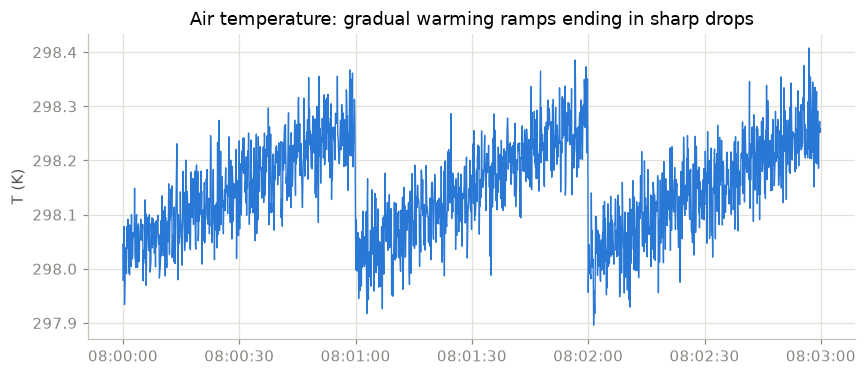

In [4]:
win = df["T"].iloc[: int(3 * 60 * 10)]  # first 3 minutes at 10 Hz

fig, ax = plt.subplots()
ax.plot(win.index, win.to_numpy(), color=C_BLUE, lw=0.9)
ax.set_ylabel("T (K)")
ax.set_title("Air temperature: gradual warming ramps ending in sharp drops")
plt.show()

## Configure and run the pipeline

`PipelineConfig` collects everything: the sampling frequency, the
block-averaging period, the flux method, the coordinate-rotation scheme used
for the friction velocity $u_*$, and the stability screens that decide the
per-block `passed` flag. Here we keep the defaults for the screens and use
the Snyder (1996) structure-function method, which needs only temperature.

`rotation="double"` (yaw + pitch per record) is a good choice for short
records like this one; the default `"planar_fit"` is preferable for long
multi-day datasets on sloping terrain.

In [5]:
cfg = PipelineConfig(
    fs=10.0,            # sampling frequency (Hz)
    block="30min",      # block-averaging period (pandas offset alias)
    method="snyder",    # snyder | chen97 | fvs | castellvi | wavelet
    rotation="double",  # rotation scheme used for u*
)

out = run_surface_renewal(df, cfg=cfg)
out[["H_uncal", "LE_resid", "tau_star", "ustar", "stdT", "passed"]].round(3)

,H_uncal,LE_resid,tau_star,ustar,stdT,passed
2023-06-01 08:29:59.900,5.696,389.164,75.665,0.221,0.112,True
2023-06-01 08:59:59.900,9.703,449.636,68.088,0.232,0.166,True
2023-06-01 09:29:59.900,13.289,495.186,62.642,0.244,0.209,True
2023-06-01 09:59:59.900,15.349,519.903,61.311,0.252,0.232,True
2023-06-01 10:29:59.900,14.886,520.657,61.856,0.250,0.232,True
2023-06-01 10:59:59.900,13.322,495.413,63.361,0.245,0.208,True
2023-06-01 11:29:59.900,9.850,449.580,65.723,0.230,0.166,True
2023-06-01 11:59:59.900,5.863,389.086,75.706,0.221,0.113,True


One row per 30-minute block, indexed by block **end** time:

- `H_uncal` — the uncalibrated sensible heat flux (W m⁻²). Snyder-method
  fluxes must be scaled by a fitted factor $\alpha$ against an
  eddy-covariance reference before use — that workflow is
  [tutorial 3](03_calibration.ipynb).
- `LE_resid` — the residual latent heat `Rn − G − H_uncal`, available because
  the record carries `Rn` and `G`.
- `tau_star` — the recovered ramp period (s); ≈ 60–75 s here, consistent with
  the 60 s ramps we synthesised.
- `ustar`, `stdT` — block diagnostics feeding the stability screens (the full
  output carries more: `zeta`, `CT2`, `S3_tau`, `frac_qc_flagged`, … — see the
  [quick start](../quickstart.md) for the complete column list).
- `passed` — `True` when the block clears the configured `u_*`, $\sigma_T$ and
  relative-$S_3$ thresholds. Use it to filter before any downstream analysis.

The flux rises toward the middle of the record and falls again, following the
convective envelope built into the synthetic data:

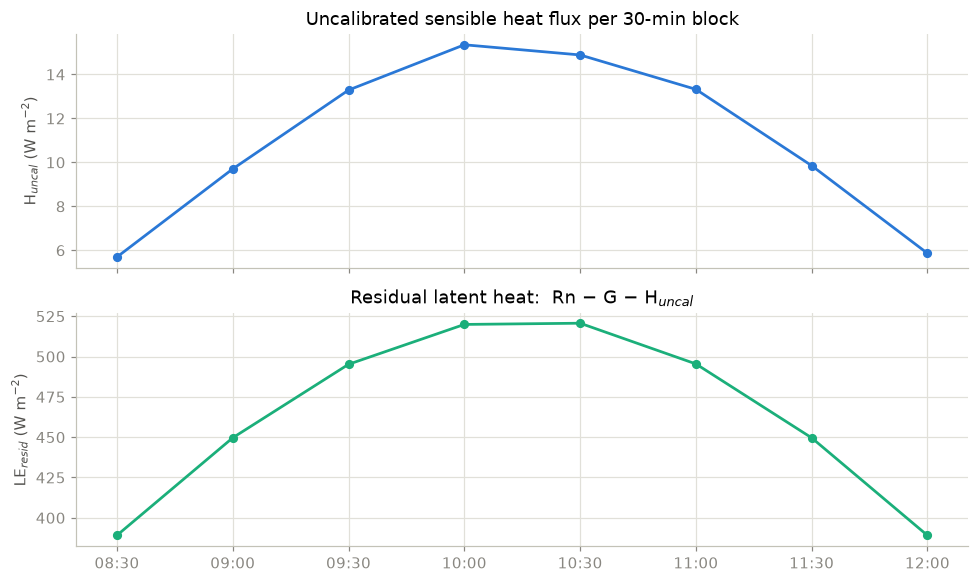

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(9.0, 5.4), sharex=True)

axes[0].plot(out.index, out["H_uncal"], color=C_BLUE, marker="o", ms=5)
axes[0].set_ylabel("H$_{uncal}$ (W m$^{-2}$)")
axes[0].set_title("Uncalibrated sensible heat flux per 30-min block")

axes[1].plot(out.index, out["LE_resid"], color=C_AQUA, marker="o", ms=5)
axes[1].set_ylabel("LE$_{resid}$ (W m$^{-2}$)")
axes[1].set_title("Residual latent heat:  Rn − G − H$_{uncal}$")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.tight_layout()
plt.show()

## Under the hood: the third-order structure function

The structure-function methods locate the ramps through
$S_3(r) = \langle (T(t+r) - T(t))^3 \rangle$. For warming ramps the small
positive increments along the ramp are overwhelmed (once cubed) by the rare
large negative drop, so $S_3$ is **negative** and its shape over lag $r$
encodes the ramp amplitude and period. The pipeline scans lags and picks the
optimal one with `pick_optimal_lag` (the maximum of $|S_3(r)|/r$).

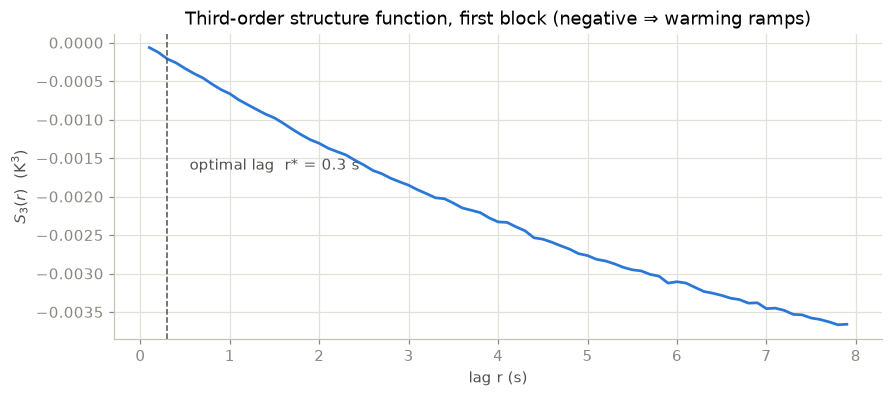

In [7]:
from surface_renewal import structure_functions, pick_optimal_lag

T_block = df["T"].iloc[: int(30 * 60 * 10)].to_numpy()  # first 30-min block
lags = np.arange(1, int(8.0 * 10))                      # 0.1 s ... 8 s at 10 Hz

S = structure_functions(T_block, lags, orders=(3,))
k_opt = pick_optimal_lag(S[3], lags)

fig, ax = plt.subplots()
ax.plot(lags / 10.0, S[3], color=C_BLUE)
ax.axvline(k_opt / 10.0, color=C_INK, lw=1.0, ls="--")
ax.text(k_opt / 10.0 + 0.25, S[3].min() * 0.45,
        f"optimal lag  r* = {k_opt / 10.0:.1f} s", color="#52514e")
ax.set_xlabel("lag r (s)")
ax.set_ylabel("$S_3(r)$  (K$^3$)")
ax.set_title("Third-order structure function, first block (negative ⇒ warming ramps)")
plt.show()

## Where to go next

- **[Comparing the five SR methods](02_method_comparison.ipynb)** — run
  `snyder`, `chen97`, `fvs`, `castellvi` and `wavelet` on identical
  preprocessed data and quantify their agreement.
- **[Calibrating against an eddy-covariance reference](03_calibration.ipynb)**
  — fit the block-scale $\alpha$ that turns `H_uncal` into `H_cal`.
- The [method-selection guide](../methods.md) explains which method fits which
  site, and [the theory page](../theory.md) collects the governing equations.